<a href="https://colab.research.google.com/github/takuya0724/sticker-pro/blob/main/StickerPro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

キャラクター画像を選択してください


Saving 1773413033311.png to 1773413033311.png
読み込み完了：1773413033311.png
画像サイズ：(768, 1376)


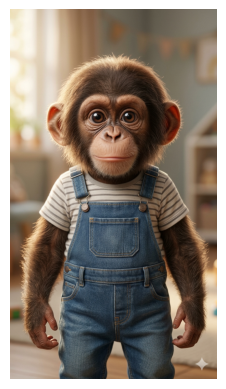

16分割画像を選択してください


In [ ]:

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

print("キャラクター画像を選択してください")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = Image.open(filename)

print(f"読み込み完了：{filename}")
print(f"画像サイズ：{img.size}")

plt.imshow(img)
plt.axis("off")
plt.show()
from PIL import Image
from google.colab import files
import os
import zipfile

LINE_SIZE = 512
PADDING = 40   # 余白（小さくするとキャラが大きくなる）

print("16分割画像を選択してください")

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGBA")

w, h = img.size

cols = 4
rows = 4

cell_w = w // cols
cell_h = h // rows

os.makedirs("stickers", exist_ok=True)

count = 1

for y in range(rows):
    for x in range(cols):

        crop = img.crop((
            x * cell_w,
            y * cell_h,
            (x + 1) * cell_w,
            (y + 1) * cell_h
        ))

        # 透明部分を除いた範囲を取得
        bbox = crop.getbbox()

        if bbox:
            crop = crop.crop(bbox)

        # LINE用キャンバス
        canvas = Image.new("RGBA", (LINE_SIZE, LINE_SIZE), (0,0,0,0))

        cw, ch = crop.size

        scale = min(
            (LINE_SIZE - PADDING*2) / cw,
            (LINE_SIZE - PADDING*2) / ch
        )

        nw = int(cw * scale)
        nh = int(ch * scale)

        crop = crop.resize((nw, nh), Image.LANCZOS)

        px = (LINE_SIZE - nw) // 2
        py = (LINE_SIZE - nh) // 2

        canvas.paste(crop, (px, py), crop)

        canvas.save(f"stickers/sticker_{count:02}.png")

        count += 1

zipname = "stickers.zip"

with zipfile.ZipFile(zipname, "w") as z:
    for f in sorted(os.listdir("stickers")):
        z.write(os.path.join("stickers", f), f)

files.download(zipname)

print("完成！")